# 3. nedēļa: Klasifikācija

## 1. uzdevums. Sagatavo datus modelēšanai

Šajā uzdevumā tiek ielādēta 2. nedēļā sagatavotā tīrā datu kopa, definēti `X` un `y`, un dati sadalīti treniņa un testa kopās.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
df.head()


Datu kopa: 12330 rindas, 28 kolonnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration
0,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.326469
1,0,-0.457191,0,-0.244931,2,-0.590903,-0.457683,1.171473,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.293024
2,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.326469
3,0,-0.457191,0,-0.244931,2,-0.622954,0.573535,1.994610,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.325076
4,0,-0.457191,0,-0.244931,10,-0.296430,-0.045196,0.142551,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-0.998552


### 1.2. Definē X un y

`Revenue` ir target mainīgais, jo tas parāda, vai klients veica pirkumu. Visas pārējās kolonnas tiek izmantotas kā ievades pazīmes (`features`).


In [19]:
# Target mainīgais — vai klients veica pirkumu
y = df['Revenue']

# Features — visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print('Target sadalījums:')
print(y.value_counts())
print()
print(f"Pirkumu īpatsvars: {y.mean():.1%}")


Features skaits: 27
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


### 1.3. Sadali datus treniņa un testa kopās

Izmantojam `stratify=y`, lai pirkumu un nepirkumu proporcija treniņa un testa kopās paliktu līdzīga visai datu kopai. Tas ir svarīgi, jo klašu sadalījums nav pilnīgi vienāds.

Sadalījums `80/20` ir bieži izmantota izvēle, jo tas dod pietiekami daudz datu modeļa trenēšanai un vienlaikus atstāj atsevišķu testa kopu godīgai novērtēšanai.


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print()
print('Target sadalījums treniņa kopā:')
print(y_train.value_counts(normalize=True).round(3))


Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


## 2. uzdevums. Trenē pirmo modeli — Decision Tree


### 2.1. Uztrenē Decision Tree klasifikatoru

Šajā solī tiek izveidots `DecisionTreeClassifier` modelis ar `max_depth=5`, lai koks nebūtu pārāk dziļš un būtu vieglāk kontrolēt pārpielāgošanos.


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))


=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



### 2.2. Confusion matrix


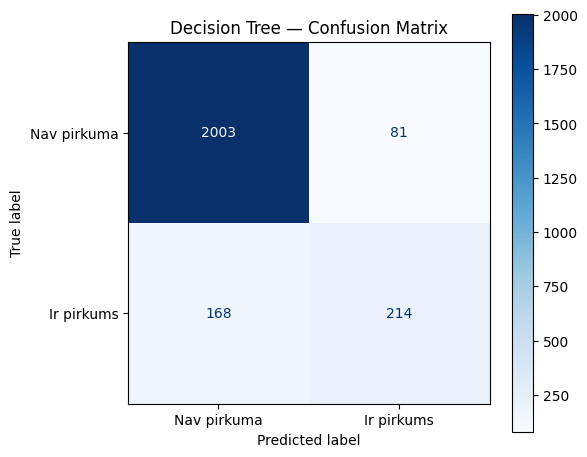

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()


### 2.3. Pārbaudi overfitting (train vs test)


In [23]:
from sklearn.metrics import accuracy_score, f1_score

dt_train_pred = dt_model.predict(X_train)

print(f"Train accuracy: {accuracy_score(y_train, dt_train_pred):.3f}")
print(f"Test accuracy: {accuracy_score(y_test, dt_pred):.3f}")
print()
print(f"Train F1: {f1_score(y_train, dt_train_pred):.3f}")
print(f"Test F1: {f1_score(y_test, dt_pred):.3f}")


Train accuracy: 0.912
Test accuracy: 0.899

Train F1: 0.683
Test F1: 0.632


### 2.4. Interpretē rezultātus

`Precision` parāda, cik precīzi modelis atpazīst pirkumus starp visām sesijām, kurām tas paredzēja pirkumu. `Recall` parāda, cik lielu daļu no īstajiem pirkumiem modelis spēj atrast.

`Confusion matrix` skaitļi rāda četrus scenārijus:
- `TN`: modelis pareizi atpazina sesiju bez pirkuma.
- `TP`: modelis pareizi atpazina sesiju ar pirkumu.
- `FP`: modelis prognozēja pirkumu, bet klients nepirka. DataShop kontekstā tas var nozīmēt nevajadzīgi iztērētu mārketinga budžetu, piemēram, nosūtītu atlaidi klientam, kurš tāpat nepirktu.
- `FN`: modelis neprognozēja pirkumu, bet klients patiesībā pirka. Tas var nozīmēt zaudētu iespēju aktivizēt potenciālo pircēju.

DataShop situācijā bieži sāpīgāks ir `FN`, jo tad uzņēmums palaida garām klientu, kurš bija tuvu pirkumam.

Overfitting pazīmes meklē, salīdzinot `train` un `test` rezultātus. Ja `train accuracy` un `train F1` ir ievērojami augstāki nekā `test` rādītāji, modelis pārāk labi iegaumē treniņa datus un sliktāk vispārina uz jauniem datiem.


## 3. uzdevums. Trenē otro modeli — Random Forest


### 3.1. Uztrenē Random Forest klasifikatoru

Random Forest veido vairākus lēmumu kokus un apvieno to prognozes, tāpēc tas parasti ir stabilāks nekā viens atsevišķs Decision Tree.


In [24]:
from sklearn.ensemble import RandomForestClassifier

# Izveido un uztrenē modeli
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Prognozes uz testa kopas
rf_pred = rf_model.predict(X_test)
print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))


=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      2084
           1       0.77      0.55      0.64       382

    accuracy                           0.91      2466
   macro avg       0.85      0.76      0.79      2466
weighted avg       0.90      0.91      0.90      2466



### 3.2. Confusion matrix


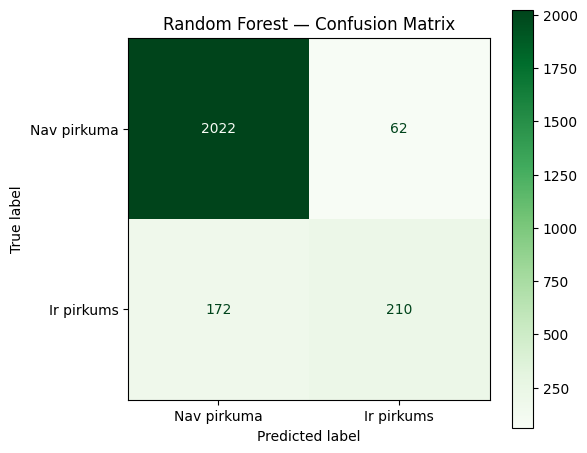

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()


### 3.3. Interpretē rezultātus

Random Forest rezultātos svarīgākie rādītāji “pirks” klasei ir `precision`, `recall` un `F1-score`. Tos var tieši salīdzināt ar Decision Tree rezultātiem, lai redzētu, vai modelis labāk atrod pirkumus un vai retāk kļūdās.

Ja `FN` ir mazāk, tas nozīmē, ka modelis retāk palaiž garām potenciālos pircējus. Ja `FP` ir mazāk, tas nozīmē, ka uzņēmums retāk tērē mārketinga budžetu klientiem, kuri tik un tā nepirktu.

Random Forest parasti mazāk pārmācās nekā viens Decision Tree, jo tas balstās uz daudzu koku kopīgu lēmumu. Šo var saprast kā “pūļa gudrības” principu: viena koka kļūdas var kompensēt citi koki, tāpēc kopējais modelis parasti vispārina labāk.


## 4. uzdevums. Salīdzini modeļus


### Sagatavo Logistic Regression modeli salīdzinājumam

Lai varētu salīdzināt visus trīs modeļus vienā vietā, vispirms tiek uztrenēts arī `Logistic Regression` klasifikators.


In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))


=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



### 4.1. F1 score salīdzinājums


In [27]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))


            Modelis  F1 Score
      Decision Tree  0.632201
      Random Forest  0.642202
Logistic Regression  0.482270


### 4.2. Vizuāls salīdzinājums


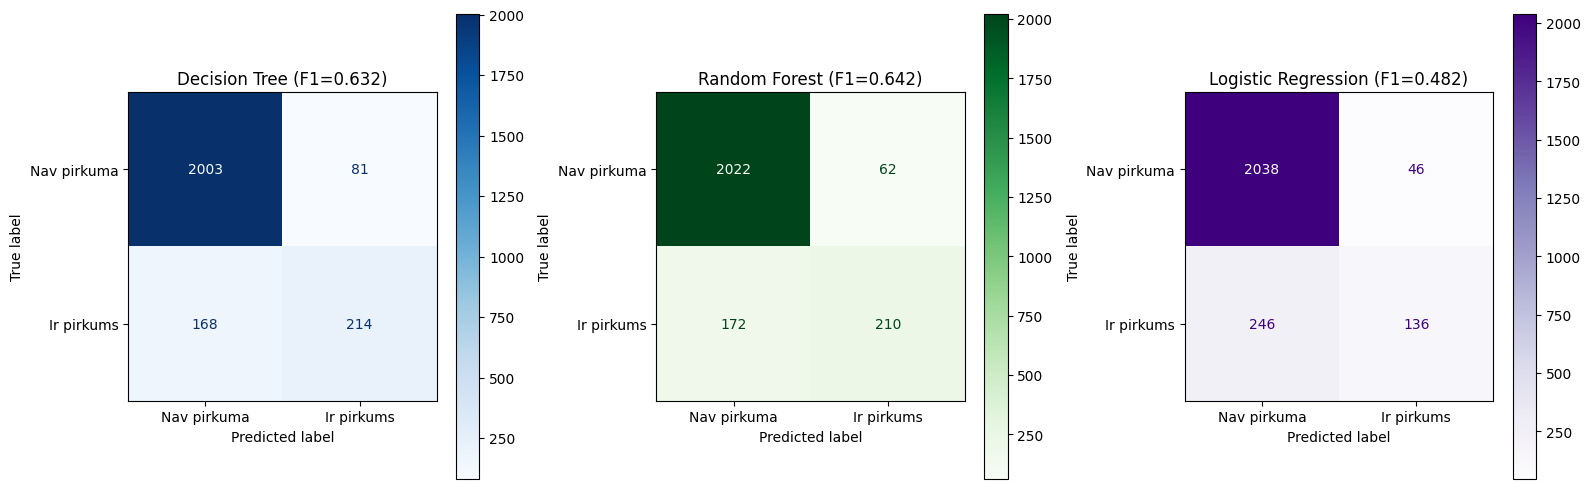

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()


### 4.3. Feature importance


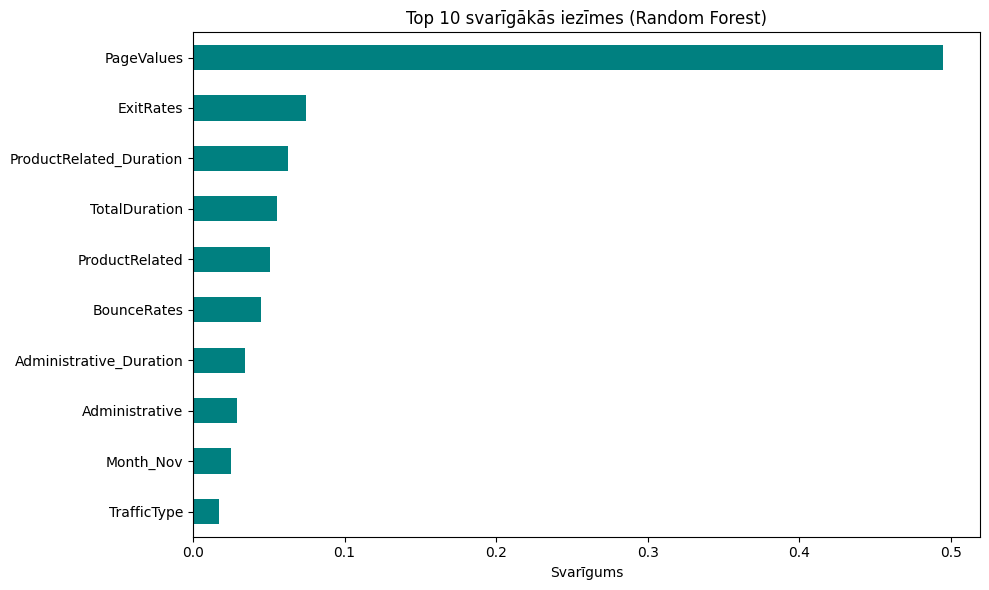

PageValues                 0.494462
ExitRates                  0.074877
ProductRelated_Duration    0.062543
TotalDuration              0.055242
ProductRelated             0.050539
BounceRates                0.044924
Administrative_Duration    0.034410
Administrative             0.029214
Month_Nov                  0.025309
TrafficType                0.017483
dtype: float64


In [29]:
# Kuras iezīmes visvairāk ietekmē prognozi?
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp.head(10))


### 4.4. Secinājumi

No trim salīdzinātajiem modeļiem labākais pēc `F1 score` ir `Random Forest` ar rezultātu ap `0.642`, kam seko `Decision Tree` ar ap `0.632`, bet `Logistic Regression` atpaliek ar ap `0.482`. Šajā uzdevumā `F1 score` ir piemērotāks par `accuracy`, jo pirkumu klase ir mazākumā: modelis, kas gandrīz vienmēr prognozētu `nepirks`, varētu iegūt augstu `accuracy`, bet ļoti vāju rezultātu tieši pirkumu atpazīšanā. No `Random Forest` svarīguma grafika redzams, ka lielāko ietekmi uz prognozi dod `PageValues`, `ExitRates`, `ProductRelated_Duration`, `TotalDuration` un `ProductRelated`, un tas biznesa ziņā ir loģiski, jo šīs iezīmes raksturo lietotāja iesaisti un tuvošanos pirkumam. `Logistic Regression` priekšrocība ir `predict_proba()`, kas dod pirkuma varbūtības, tāpēc e-komercijas vadītājs varētu izmantot modeli klientu segmentēšanai, piemēram, sūtot atlaides vai atgādinājumus tiem lietotājiem, kuriem pirkuma iespējamība ir vidēji augsta, bet vēl nav pietiekami droša.


## 5. uzdevums. Trenē trešo modeli — Logistic Regression


### 5.1. Uztrenē Logistic Regression klasifikatoru

Šeit Logistic Regression tiek parādīts kā atsevišķs modelis ar savu interpretāciju. Tas ir lineārs klasifikācijas modelis, kas īpaši noder, jo dabiski dod arī pirkuma varbūtības.


In [30]:
from sklearn.linear_model import LogisticRegression

# Izveido un uztrenē modeli
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Prognozes uz testa kopas
lr_pred = lr_model.predict(X_test)
print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))


=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.75      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



### 5.2. Varbūtību analīze


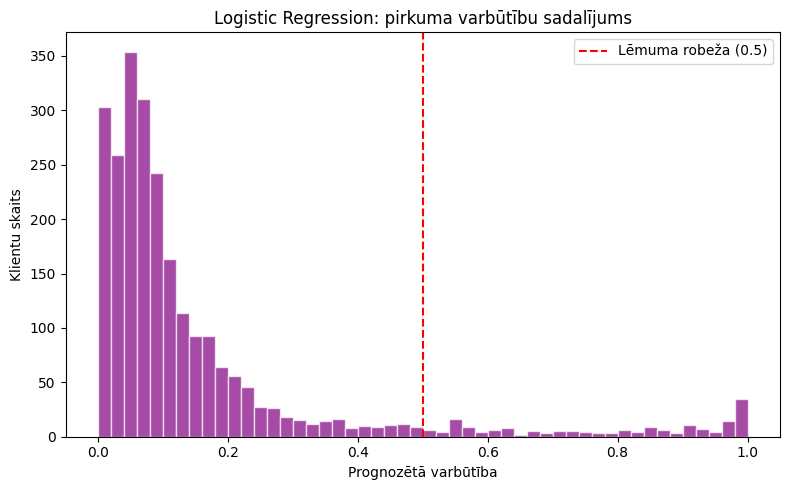

Varbūtību kopsavilkums:
count    2466.000
mean        0.153
std         0.207
min         0.000
25%         0.044
50%         0.081
75%         0.163
max         1.000
dtype: float64


In [31]:
# Varbūtības katram klientam
lr_proba = lr_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
plt.hist(lr_proba, bins=50, color='purple', edgecolor='white', alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Lēmuma robeža (0.5)')
plt.title('Logistic Regression: pirkuma varbūtību sadalījums')
plt.xlabel('Prognozētā varbūtība')
plt.ylabel('Klientu skaits')
plt.legend()
plt.tight_layout()
plt.show()

print('Varbūtību kopsavilkums:')
print(pd.Series(lr_proba).describe().round(3))


### 5.3. Confusion matrix


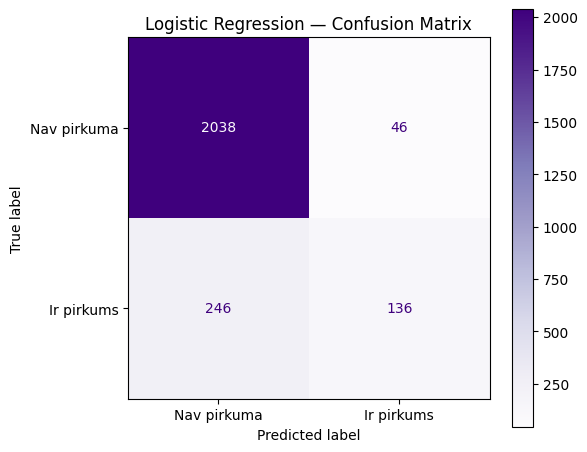

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()


### 5.4. Interpretē rezultātus

`Logistic Regression` šajā darbā sasniedza `F1 score` ap `0.482`, kas ir zemāks nekā `Decision Tree` (`0.632`) un `Random Forest` (`0.642`). Tas nozīmē, ka šis modelis kopumā sliktāk sabalansē `precision` un `recall` pirkumu klasei nekā pārējie divi modeļi.

Varbūtību histogramma nerāda ļoti skaidru atdalījumu starp pircējiem un nepircējiem, jo liela daļa prognozēto varbūtību ir zem `0.5`, un mediāna ir tikai ap `0.081`. Tas nozīmē, ka modelis daudzās situācijās nav pietiekami pārliecināts, lai prognozētu pirkumu.

Biznesa ziņā `Logistic Regression` priekšrocība ir tā, ka ar `predict_proba()` var sakārtot klientus pēc pirkuma varbūtības un mārketinga budžetu novirzīt prioritāri tiem, kuri ir tuvāk pirkumam. Confusion matrix rāda, ka šim modelim ir salīdzinoši maz `FP` (46), tātad tas labāk saudzē mārketinga budžetu, bet daudz `FN` (246), tātad tas biežāk palaiž garām potenciālos pircējus nekā `Decision Tree` vai `Random Forest`.


## 6. uzdevums. BONUS — KNN klasifikators


### 6.1. Uztrenē KNN klasifikatoru

KNN balstās uz attālumu starp punktiem, tāpēc pirms modeļa trenēšanas ievades pazīmes tiek pārmērogotas ar `StandardScaler`. Tas ir svarīgi, lai iezīmes ar lielāku skalu nedominētu attāluma aprēķinā.


In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Pārmēro datus tieši KNN modelim
knn_scaler = StandardScaler()
X_train_knn = knn_scaler.fit_transform(X_train)
X_test_knn = knn_scaler.transform(X_test)

# KNN ar 5 kaimiņiem
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_knn, y_train)
knn_pred = knn_model.predict(X_test_knn)

print("=== KNN rezultāti ===")
print(classification_report(y_test, knn_pred))


=== KNN rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      2084
           1       0.64      0.36      0.46       382

    accuracy                           0.87      2466
   macro avg       0.77      0.66      0.69      2466
weighted avg       0.85      0.87      0.85      2466



### 6.2. Confusion matrix un salīdzinājums


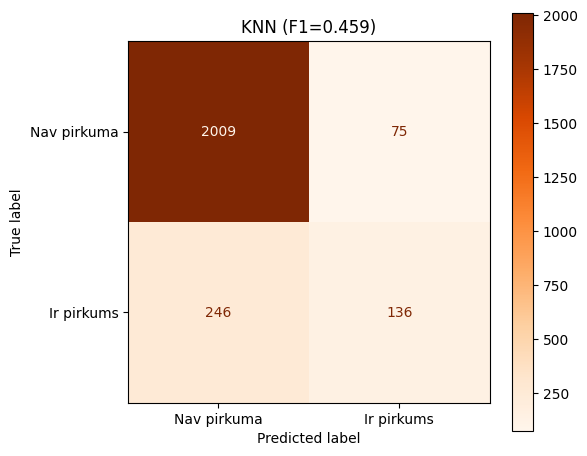

            Modelis  F1 Score
      Decision Tree  0.632201
      Random Forest  0.642202
Logistic Regression  0.482270
                KNN  0.458685


In [34]:
knn_f1 = f1_score(y_test, knn_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, knn_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Oranges', ax=ax
)
ax.set_title(f'KNN (F1={knn_f1:.3f})')
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression', 'KNN'],
    'F1 Score': [dt_f1, rf_f1, lr_f1, knn_f1]
})
print(comparison.to_string(index=False))


### 6.3. Interpretē rezultātus

`KNN` šajā darbā sasniedza `F1 score` ap `0.459`, kas ir zemāks nekā `Decision Tree` (`0.632`), `Random Forest` (`0.642`) un arī nedaudz zemāks nekā `Logistic Regression` (`0.482`). Tas nozīmē, ka uz šīs datu kopas KNN nav labākais risinājums, pat ja dati tika papildus pārmērogoti tieši šim modelim.

KNN priekšrocība ir vienkāršība un tas, ka nav klasiskas sarežģītas trenēšanas fāzes, taču praksē šo ne vienmēr kompensē tā trūkumi. KNN ir jutīgs pret mērogošanu, var būt lēnāks uz lielākām datu kopām un šeit tas pirkumu klasi atpazina vājāk nekā koku modeļi.

Ja būtu iespēja eksperimentēt tālāk, loģiski būtu pārbaudīt vairākas `K` vērtības, piemēram, `3`, `5`, `7` un `9`, un izvēlēties to, kas dod labāko `F1 score`. `K=1` ir riskanti, jo modelis kļūst pārāk jutīgs pret atsevišķiem trokšņainiem vai netipiskiem punktiem un tāpēc sliktāk vispārina uz jauniem datiem.
